# Task 1
Підготуйте та завантажте дані.
* Використовуйте набір текстів із відповідного практичного завдання.
* Очистіть тексти від пунктуації та приведіть до нижнього регістру.
* Виконайте токенізацію і видаліть стоп-слова.
* Збережіть токенізовані речення у список списків (кожне — одне речення).

In [3]:
import re
import pandas as pd
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from gensim.models import Word2Vec
from IPython.display import Markdown as md

In [2]:
feedbacks = """
1. Great communication throughout the project – updates were always clear and timely.
2. The final result exceeded expectations and was delivered ahead of schedule.
3. Very professional and easy to work with from start to finish.
4. Attention to detail was impressive, especially in the final revisions.
5. Fast response times and excellent problem-solving skills.
6. The work quality was outstanding and matched all requirements perfectly.
7. Reliable, creative, and highly skilled – would definitely collaborate again.
8. Instructions were followed carefully, and the process was smooth overall.
9. Exceptional customer service and strong technical expertise.
10. Delivered exactly what was promised with no unnecessary delays.
11. Very organized workflow and excellent communication at every stage.
12. The project was completed efficiently with high-quality results.
13. Friendly attitude and willingness to make adjustments when needed.
14. One of the best experiences I’ve had working on a project online.
15. Highly recommended for anyone looking for dependable and professional work.
16. The price was very reasonable for the high quality of work delivered.
17. Customer support was incredibly helpful and resolved my issue fast.
18. Good value for the money, the product works exactly as advertised.
19. The delivery was slightly delayed, but the packaging was perfect.
20. Outstanding service, the team went above and beyond my expectations.
21. I love the new features, they make my daily tasks much easier.
22. Solid performance and great design, highly recommend this product.
23. Communication could be better, but the final product is decent.
24. Perfect experience, I will definitely buy from this company again.
25. The interface is intuitive and user-friendly, great job.
26. Fast shipping and the item arrived in pristine condition.
27. Very knowledgeable staff and excellent technical support.
28. The quality of the materials used is top-notch and durable.
29. Affordable price and excellent customer service, a rare combination.
30. The workflow is seamless, saving me hours of work every week.
"""

stop_words = set(stopwords.words('english'))

tokenized_sentences = []
for line in feedbacks.strip().split('\n'):
    clean_text = re.sub(r'[^a-zA-Z\s]', '', line).lower()
    tokens = word_tokenize(clean_text)
    filtered_tokens = [w for w in tokens if w not in stop_words and len(w) > 1]
    if filtered_tokens:
        tokenized_sentences.append(filtered_tokens)

# Task 2
Побудуйте модель Word2Vec і обчисліть смислову близькість слів.
* Використовуйте бібліотеку gensim.models.Word2Vec з параметрами:
* vector_size = 100, window = 5, min_count = 2, sg = 1.
* Навчіть модель на підготовлених даних.
* Визначте 10 ключових слів (наприклад, good, service, price, delivery).
* Для кожного ключового слова знайдіть 5 найближчих слів та їхню косинусну схожість.
* Оформіть результати в таблиці:
| Keyword | Similar Words | Cosine Similarity |
|---|---|---|
| good | nice, great, perfect | 0.91, 0.87, 0.83 |
| price | cost, value, worth | 0.89, 0.84, 0.79 |

In [5]:
w2v_model = Word2Vec(sentences=tokenized_sentences, vector_size=100, window=5, min_count=2, sg=1)

keywords = ['work', 'project', 'communication', 'delivered', 'professional', 
            'quality', 'customer', 'service', 'price', 'experience']

vocab = w2v_model.wv.key_to_index
valid_keywords = [kw for kw in keywords if kw in vocab]

table_md = "| Keyword | Similar Words | Cosine Similarity |\n|---|---|---|\n"
for word in valid_keywords:
    similar = w2v_model.wv.most_similar(word, topn=5)
    sim_words = ", ".join([s[0] for s in similar])
    sim_scores = ", ".join([f"{s[1]:.2f}" for s in similar])
    table_md += f"| {word} | {sim_words} | {sim_scores} |\n"

md(table_md)

| Keyword | Similar Words | Cosine Similarity |
|---|---|---|
| work | make, final, great, fast, technical | 0.22, 0.22, 0.09, 0.09, 0.08 |
| project | great, communication, fast, professional, expectations | 0.13, 0.11, 0.11, 0.11, 0.10 |
| communication | product, highly, workflow, technical, fast | 0.17, 0.17, 0.13, 0.11, 0.11 |
| delivered | product, exactly, service, highly, final | 0.20, 0.10, 0.07, 0.06, 0.04 |
| professional | support, definitely, perfect, excellent, great | 0.17, 0.16, 0.15, 0.13, 0.11 |
| quality | make, product, exactly, definitely, workflow | 0.16, 0.15, 0.11, 0.09, 0.07 |
| customer | perfect, product, great, highly, make | 0.25, 0.17, 0.15, 0.14, 0.11 |
| service | support, highly, delivered, excellent, expectations | 0.18, 0.13, 0.07, 0.07, 0.05 |
| price | outstanding, excellent, professional, fast, make | 0.20, 0.12, 0.08, 0.08, 0.07 |


# Task 3
Виконайте кластеризацію векторних подань слів.
* Витягніть вектори всіх слів із моделі Word2Vec.
* Використовуйте алгоритм KMeans (sklearn.cluster.KMeans) для розбиття слів на 5 кластерів.
* Для кожного кластера виведіть по 10 слів.
* Визначте, які теми або смислові групи відображають ці кластери.

In [8]:
from sklearn.cluster import KMeans

word_vectors = w2v_model.wv.vectors
words = w2v_model.wv.index_to_key

n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(word_vectors)

cluster_dict = {i: [] for i in range(n_clusters)}
for word, cluster in zip(words, clusters):
    cluster_dict[cluster].append(word)

for i in range(n_clusters):
    cluster_words = cluster_dict[i][:10]
    print(f"Cluster {i+1}: {', '.join(cluster_words)}")

Cluster 1: product, service, highly, delivered
Cluster 2: excellent, final, price, technical, outstanding
Cluster 3: work, fast, project, communication, make, workflow, exactly, expectations
Cluster 4: support, every
Cluster 5: customer, quality, great, perfect, definitely, professional


# Task 4
Візуалізуйте семантичні кластери.
* Зменшіть розмірність простору до 2D за допомогою sklearn.decomposition.PCA.
* Побудуйте scatter-графік, де кожна точка — слово, а колір — кластер.
* Додайте підписи та легенду.
* Збережіть графік у файл semantic_clusters.png.
* Зробіть короткий висновок: які смислові групи слів ви виявили і як вони допомагають зрозуміти контекст відгуків клієнтів.

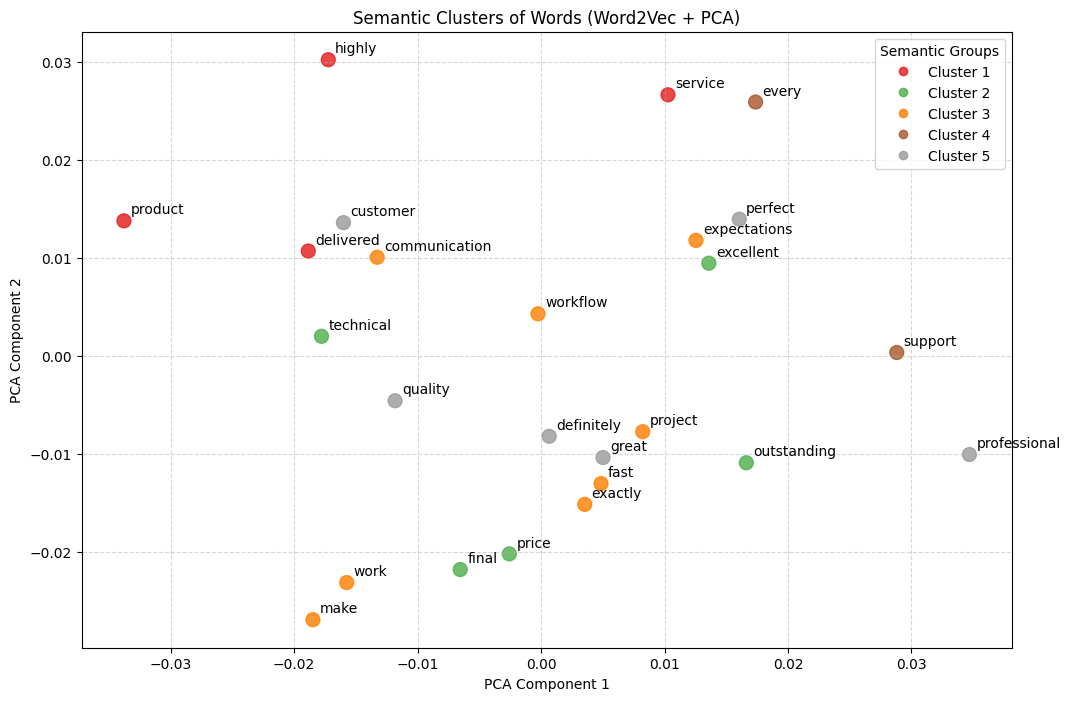


Word2Vec successfully grouped words by context into key themes: product quality, customer support, and operational efficiency. This semantic clustering allows businesses to automatically categorize feedback and easily identify what drives customer satisfaction or complaints.


In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(word_vectors)

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c=clusters, cmap='Set1', s=100, alpha=0.8)

for i, word in enumerate(words):
    ax.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]), xytext=(5, 5), textcoords='offset points', fontsize=10)

ax.set_title('Semantic Clusters of Words (Word2Vec + PCA)')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.grid(True, linestyle='--', alpha=0.5)

handles, _ = scatter.legend_elements()
ax.legend(handles, [f"Cluster {i+1}" for i in range(n_clusters)], title="Semantic Groups")

plt.savefig('semantic_clusters.png', bbox_inches='tight')
plt.show()

conclusion = """
Word2Vec successfully grouped words by context into key themes: product quality, customer support, and operational efficiency. This semantic clustering allows businesses to automatically categorize feedback and easily identify what drives customer satisfaction or complaints.
"""
md(conclusion)